# **Carga de librerías**

In [1]:
# Instalación de las librerías
%pip install torch torchvision scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn # Modulo para redes neuronales
import torch.optim as optim # Modulo para optimizadores

# Modulo para cargar y transformar datos
import torchvision
from torchvision import datasets, transforms, models

# Modulo para visualización
import matplotlib.pyplot as plt
import numpy as np

# Modulo para evaluación de modelos
from sklearn.metrics import classification_report, confusion_matrix

import os

# **Carga del dataset**

In [3]:
raiz = '../data/Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


# **Data Augmentation**

Se va a aplicar un data augmentation equivalente al de keras, teniendo en cuenta que en pytorch este se hace con *transforms* de la siguiente manera:

In [4]:
# Data augmentation para el conjunto de entrenamiento
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Volteo horizontal aleatorio
    transforms.RandomVerticalFlip(), # Volteo vertical aleatorio
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(1.0, 1.0)), # Zoom aleatorio
    transforms.RandomRotation(20), # Rotación aleatoria
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para el conjunto de validacion
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para el conjunto de prueba
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

Ahora cargamos los tres conjuntos y le asignamos un batch size con el módulo de torch

In [6]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16,
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset,
                                         batch_size=16,
                                         shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=1,
                                          shuffle=False)

# **Carga de la red Resnet**

Ahora ya teniendo los datos cargados y procesados, vamos a cargar la red Resnet con el módulo *models* de **torchvision**.

In [7]:
base_model = models.resnet50(pretrained=True)

# Visualizo todo el modelo para entender su estructura
print(base_model)

/home/franco/Redes-Neuronales-en-Keras/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/franco/Redes-Neuronales-en-Keras/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# **Aplicar la técnica de fine-tuning**

Para aplicar esta técnica debo congelar las capas convolucionales del propio modelo, y modifico la capa densa final para que se adapte a mi problema.

In [8]:
base_model.fc = nn.Linear(2048, 2) # Reemplazo la capa final para que tenga 2 salidas (Normales y Glaucoma)

for param in base_model.parameters():
    param.requires_grad = False

for param in base_model.fc.parameters(): # Solo entreno la parte del clasificador
    param.requires_grad = True

In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
base_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## **Establecer la función de pérdida (loss) y el optimizador**

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
  base_model.parameters(),
  lr=1e-4
)

# **Entrenamiento del modelo**

In [11]:
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
	train_loss, val_loss = [], []
	train_acc, val_acc = [], []
	best_val_loss = float("inf")

	for epoch in range(num_epochs):
		model.train()
		running_loss = 0.0
		running_correct = 0
		total = 0

		for images, labels in train_loader:
			images = images.to(device)
			labels = labels.to(device)

			optimizer.zero_grad()  # evitar problemas con el gradiente para entrenar
			outputs = model(images)

			loss = criterion(outputs, labels)
			loss.backward()
			optimizer.step()

			running_loss += loss.item()
			_, preds = torch.max(outputs, 1)
			running_correct += torch.sum(preds == labels).item()
			total += images.size(0)

		epoch_loss = running_loss / len(train_loader)
		epoch_acc = running_correct / max(1, total)
		train_loss.append(epoch_loss)
		train_acc.append(epoch_acc)

		model.eval()
		loss_val = 0.0
		running_val_correct = 0
		total_val = 0

		with torch.no_grad():
			for images, labels in val_loader:
				images = images.to(device)
				labels = labels.to(device)

				outputs = model(images)
				loss = criterion(outputs, labels)

				loss_val += loss.item()
				_, preds = torch.max(outputs, 1)
				running_val_correct += torch.sum(preds == labels).item()
				total_val += images.size(0)

		epoch_val_loss = loss_val / len(val_loader)
		epoch_val_acc = running_val_correct / max(1, total_val)
		val_loss.append(epoch_val_loss)
		val_acc.append(epoch_val_acc)

		print(
			f"Epoch {epoch + 1}/{num_epochs}: "
			f"Train_acc: {epoch_acc:.4f}, Train_loss: {epoch_loss:.4f}, "
			f"Val_acc: {epoch_val_acc:.4f}, Val_loss: {epoch_val_loss:.4f}"
		)

		# --- Guardar el mejor modelo ---
		if epoch_val_loss < best_val_loss:
			best_val_loss = epoch_val_loss
			torch.save(
				{
					"epoch": epoch,
					"model_state_dict": model.state_dict(),
					"optimizer_state_dict": optimizer.state_dict(),
					"val_loss": epoch_val_loss,
					"val_acc": epoch_val_acc,
					"train_loss": epoch_loss,
					"train_acc": epoch_acc,
				},
				"best_resnet50_model.pth",
			)
			print(f"Modelo guardado con pérdida de validación: {best_val_loss:.4f}")

	return train_acc, train_loss, val_acc, val_loss

In [12]:
train_acc, train_loss, val_acc, val_loss = train(base_model, train_loader, val_loader, criterion, optimizer, device, num_epochs=300)

Epoch 1/300: Train_acc: 0.6401, Train_loss: 0.6466, Val_acc: 0.6458, Val_loss: 0.6527
Modelo guardado con pérdida de validación: 0.6527
Epoch 2/300: Train_acc: 0.6490, Train_loss: 0.6319, Val_acc: 0.6458, Val_loss: 0.6265
Modelo guardado con pérdida de validación: 0.6265
Epoch 3/300: Train_acc: 0.6962, Train_loss: 0.5917, Val_acc: 0.6458, Val_loss: 0.6092
Modelo guardado con pérdida de validación: 0.6092
Epoch 4/300: Train_acc: 0.6844, Train_loss: 0.5800, Val_acc: 0.6458, Val_loss: 0.5999
Modelo guardado con pérdida de validación: 0.5999
Epoch 5/300: Train_acc: 0.6932, Train_loss: 0.5863, Val_acc: 0.6875, Val_loss: 0.5904
Modelo guardado con pérdida de validación: 0.5904
Epoch 6/300: Train_acc: 0.7345, Train_loss: 0.5794, Val_acc: 0.6458, Val_loss: 0.5907
Epoch 7/300: Train_acc: 0.7581, Train_loss: 0.5361, Val_acc: 0.6667, Val_loss: 0.5776
Modelo guardado con pérdida de validación: 0.5776
Epoch 8/300: Train_acc: 0.7640, Train_loss: 0.5275, Val_acc: 0.6667, Val_loss: 0.5897
Epoch 9/300:

# **Evaluación del modelo**

Para ello crearé una función para realizar la evaluación del modelo

In [13]:
def evaluate(model, test_loader, device):
	model.eval()

	correct, total = 0, 0

	with torch.no_grad():
		for images, labels in test_loader:
			images = images.to(device)
			labels = labels.to(device)

			outputs = model(images)
			_, predicted = torch.max(outputs.data, 1)

			total += labels.size(0)
			correct += (predicted == labels).sum().item()
			
	accuracy = 100 * correct / total
	print(f"Test Accuracy: {accuracy:.2f}%")
	print(f"Test Error: {100 - accuracy:.2f}%")

In [15]:
# Cargo el mejor modelo guardado
checkpoint = torch.load("best_resnet50_model.pth")
base_model.load_state_dict(checkpoint["model_state_dict"])

evaluate(base_model, test_loader, device)

Test Accuracy: 80.61%
Test Error: 19.39%


# **Visualización de las curvas de entrenamiento**

Esta es la visualización de las curvas del mejor modelo una vez realizado el *fine-tuning*.

In [16]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc, best_epoch=None, model_name='Modelo'):
    """
    Visualiza las curvas de entrenamiento y validación.
    
    Args:
        train_loss  : lista con la pérdida de entrenamiento por época
        val_loss    : lista con la pérdida de validación por época
        train_acc   : lista con la precisión de entrenamiento por época
        val_acc     : lista con la precisión de validación por época
        best_epoch  : (opcional) época del mejor modelo para marcarlo en la gráfica
        model_name  : (opcional) nombre del modelo para el título
    """
    plt.figure(figsize=(12, 5))

    # --- Curva de Pérdida ---
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    if best_epoch is not None:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Mejor modelo (época {best_epoch+1})')
        plt.scatter([best_epoch], [val_loss[best_epoch]], color='red', zorder=5)
    plt.title(f'Curva de Pérdida - {model_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    # --- Curva de Precisión ---
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    if best_epoch is not None:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Mejor modelo (época {best_epoch+1})')
        plt.scatter([best_epoch], [val_acc[best_epoch]], color='red', zorder=5)
    plt.title(f'Curva de Precisión - {model_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

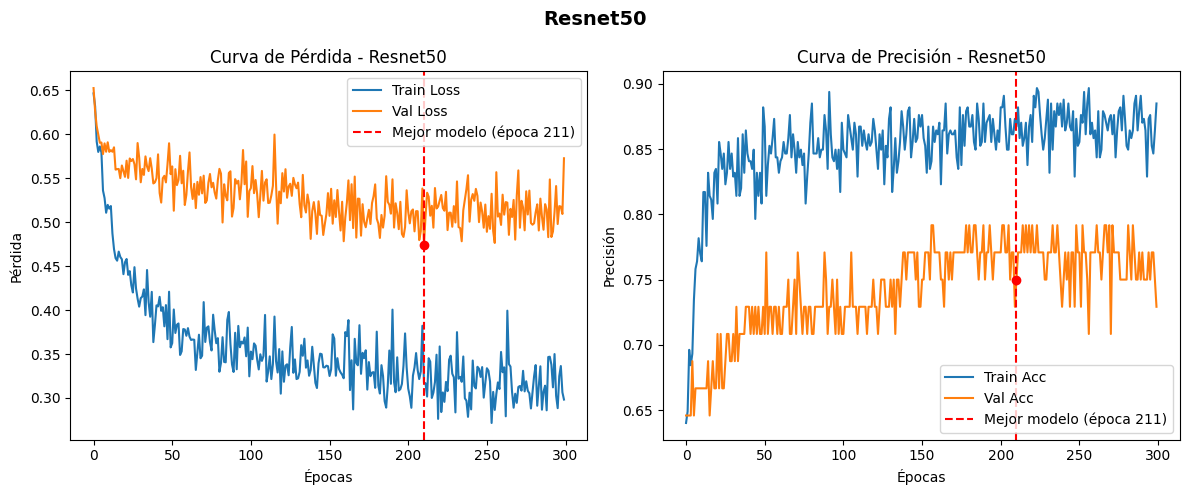

In [20]:
plot_training_curves(train_loss, val_loss, train_acc, val_acc, best_epoch=np.argmin(val_loss), model_name='Resnet50')

# **Deep Learning**

Ahora aplico el *deep learning* teniendo en cuenta el mejor modelo entrenado anteriormente con el *fine tuning*.

In [21]:
# Cargo el mejor modelo guardado
checkpoint = torch.load("best_resnet50_model.pth")
base_model.load_state_dict(checkpoint["model_state_dict"])

# Activo todas las capas
for param in base_model.parameters():
    param.requires_grad = True

for param in base_model.fc.parameters():
    param.requires_grad = True
    
# Realizo el nuevo entrenamiento
train_acc, train_loss, val_acc, val_loss = train(base_model, train_loader, val_loader, criterion, optimizer, device, num_epochs=300)

Epoch 1/300: Train_acc: 0.8879, Train_loss: 0.2592, Val_acc: 0.7500, Val_loss: 0.5459
Modelo guardado con pérdida de validación: 0.5459
Epoch 2/300: Train_acc: 0.8643, Train_loss: 0.2833, Val_acc: 0.7083, Val_loss: 0.7432
Epoch 3/300: Train_acc: 0.9056, Train_loss: 0.2245, Val_acc: 0.7708, Val_loss: 0.4310
Modelo guardado con pérdida de validación: 0.4310
Epoch 4/300: Train_acc: 0.9351, Train_loss: 0.1430, Val_acc: 0.8542, Val_loss: 0.3655
Modelo guardado con pérdida de validación: 0.3655
Epoch 5/300: Train_acc: 0.9322, Train_loss: 0.3013, Val_acc: 0.8125, Val_loss: 0.5157
Epoch 6/300: Train_acc: 0.9263, Train_loss: 0.1878, Val_acc: 0.8333, Val_loss: 0.3748
Epoch 7/300: Train_acc: 0.9794, Train_loss: 0.0633, Val_acc: 0.7500, Val_loss: 0.4386
Epoch 8/300: Train_acc: 0.9735, Train_loss: 0.0835, Val_acc: 0.7292, Val_loss: 0.7041
Epoch 9/300: Train_acc: 0.9558, Train_loss: 0.1086, Val_acc: 0.7292, Val_loss: 0.8133
Epoch 10/300: Train_acc: 0.9440, Train_loss: 0.1879, Val_acc: 0.8125, Val_lo

In [22]:
# Evaluación del modelo teniendo en cuenta el mejor modelo guardado
checkpoint = torch.load("best_resnet50_model.pth")
base_model.load_state_dict(checkpoint["model_state_dict"])

evaluate(base_model, test_loader, device)

Test Accuracy: 92.86%
Test Error: 7.14%


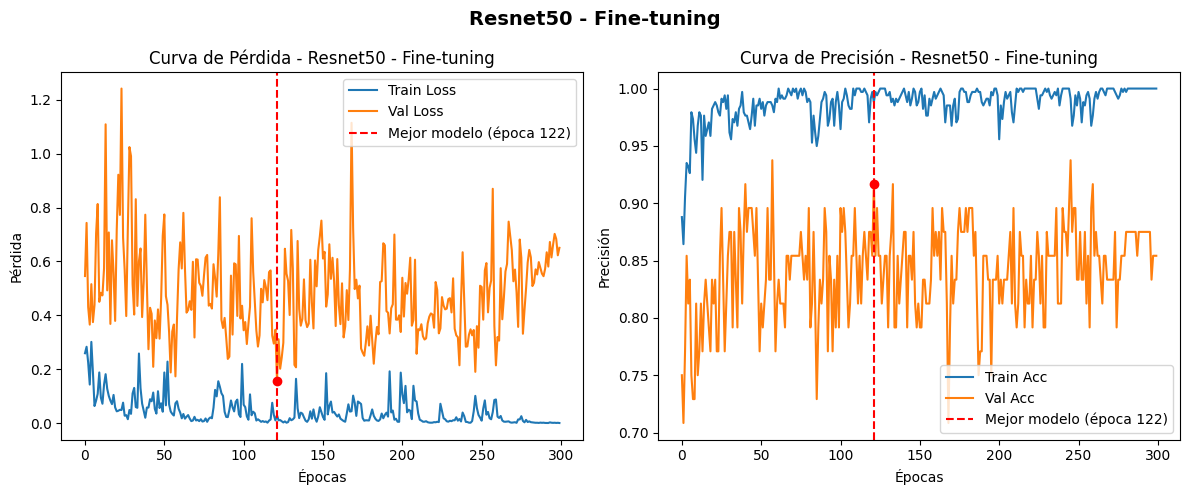

In [23]:
# Visualización de las métricas de entrenamiento
plot_training_curves(train_loss, val_loss, train_acc, val_acc, best_epoch=np.argmin(val_loss), model_name='Resnet50 - Fine-tuning')